In [5]:
#importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import roc_curve, roc_auc_score

from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage

# LOADING THE DATASET

# Replacing with the dataset path
df = pd.read_excel('Myocardial infarction dataset.xlsx')
# Assuming last column is target
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# PREPROCESSING

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [6]:
#loading the dataset (sample size = 70,000)
df = pd.read_excel("Myocardial infarction dataset.xlsx")

df.head()

,Unnamed: 0,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,0,18393,1,168,62.0,110,80,0,0,0,0,1,0
1,1,1,20228,0,156,85.0,140,90,2,0,0,0,1,1
2,2,2,18857,0,165,64.0,130,70,2,0,0,0,0,1
3,3,3,17623,1,169,82.0,150,100,0,0,0,0,1,1
4,4,4,17474,0,156,56.0,100,60,0,0,0,0,0,0


In [7]:
#checking dataset shape
df.shape

(70000, 14)

In [8]:
#DATA PREPROCESSING
#data cleaning
df = df.drop(['Unnamed: 0','id'], axis=1)

In [9]:
#since the ages of the patients are given in the form of days in the dataset,they need to be converted to years
df['age'] = df['age'] / 365

In [10]:
#checking for missing values
df.isnull().sum()

,0
age,0
gender,0
height,0
weight,0
ap_hi,0
ap_lo,0
cholesterol,0
gluc,0
smoke,0
alco,0


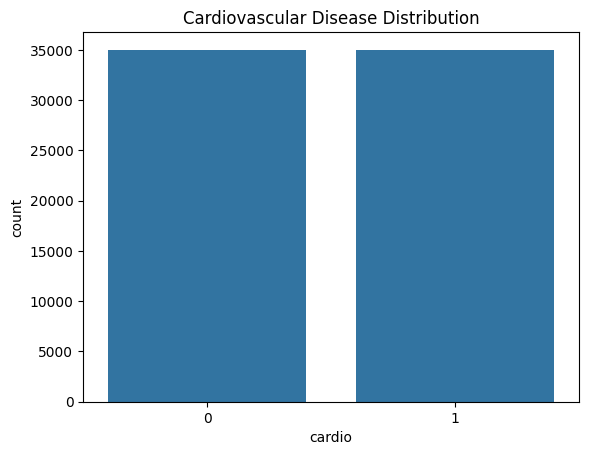

In [11]:
#distribution of target
sns.countplot(x='cardio', data=df)
plt.title("Cardiovascular Disease Distribution")
plt.show()

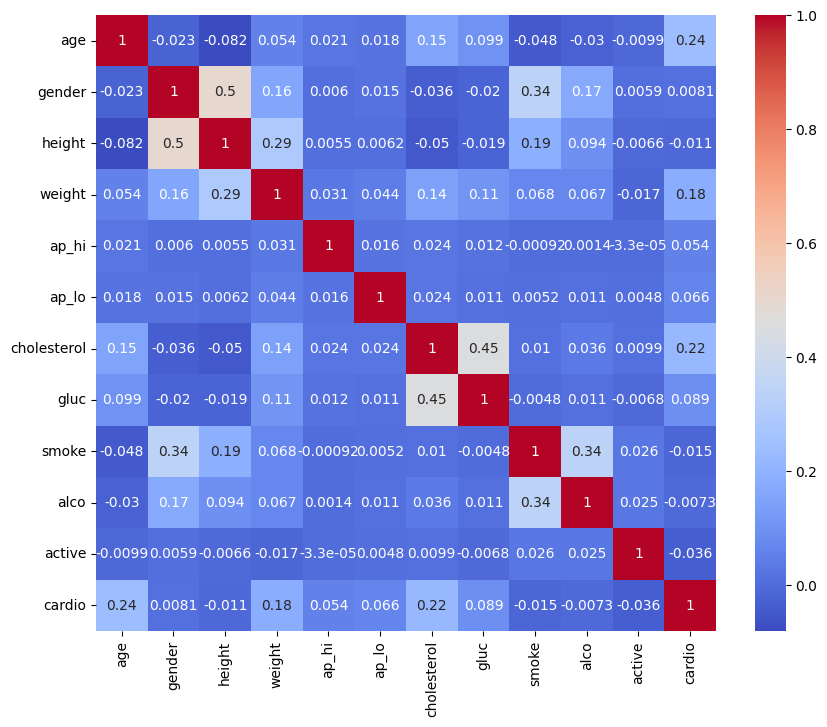

In [12]:
#correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [13]:
#train test split - separating features and label
X = df.drop('cardio', axis=1)
y = df['cardio']

In [14]:
#splitting dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [15]:
#feature scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [16]:
#MODEL TRAINING AND EVALUATION
#supervised ML - LOGISTIC REGRESSION
#training the model
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

lr.fit(X_train, y_train)

LogisticRegression()

In [17]:
#prediction by logistic regression
y_pred_lr = lr.predict(X_test)

In [18]:
#accuracy of logistic regression
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.7235714285714285


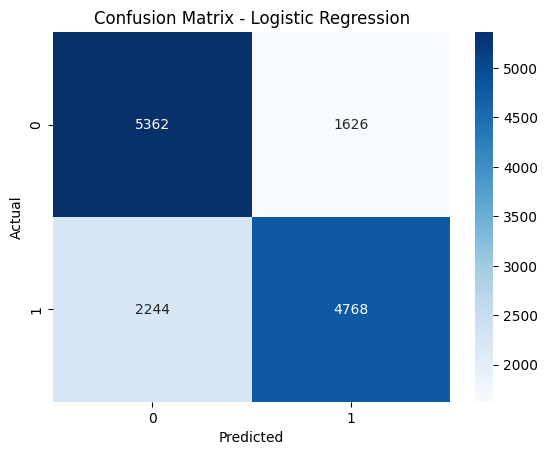

In [19]:
#confusion matrix for logistic regression
cm_lr = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [20]:
#supervised ML - RANDOM FOREST
#training the model
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200)

rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200)

In [21]:
#prediction by random forest
y_pred_rf = rf.predict(X_test)

In [22]:
#accuracy of random forest
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.7153571428571428


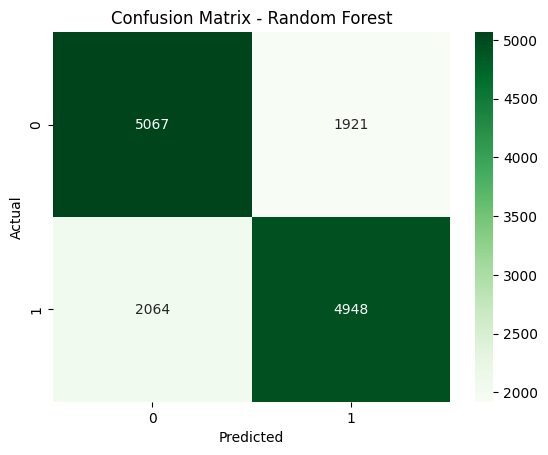

In [23]:
#confusion matrix for random forest
cm_rf = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [24]:
#supervised ML - KNN
#training the model
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

KNeighborsClassifier()

In [25]:
#prediction by knn
y_pred_knn = knn.predict(X_test)


In [26]:
#accuracy of knn
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))

KNN Accuracy: 0.6499285714285714


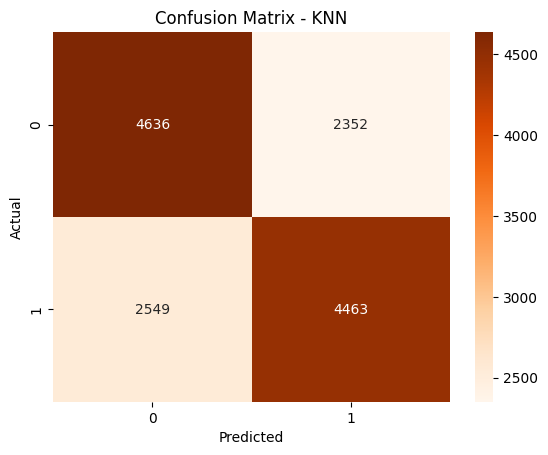

In [27]:
#confusion matrix for knn
cm_knn = confusion_matrix(y_test, y_pred_knn)

sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Oranges')

plt.title("Confusion Matrix - KNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [28]:
#supervised ML - SVM
#training the model
from sklearn.svm import SVC

svm = SVC()

svm.fit(X_train, y_train)

SVC()

In [29]:
#prediction by svm
y_pred_svm = svm.predict(X_test)
#accuracy of svm
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

SVM Accuracy: 0.7319285714285715


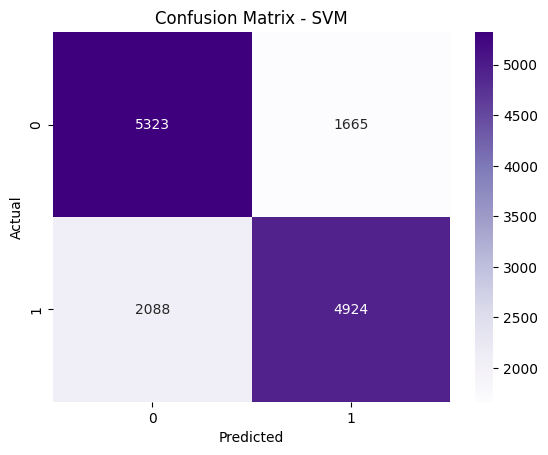

In [30]:
#confusion matrix for svm
cm_svm = confusion_matrix(y_test, y_pred_svm)

sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Purples')

plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [31]:
#supervised ML - GRADIENT BOOSTING
#training the model
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier()

gb.fit(X_train, y_train)

GradientBoostingClassifier()

In [32]:
#prediction by gradient boosting
y_pred_gb = gb.predict(X_test)

In [33]:
#accuracy of gradient boosting
print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))

Gradient Boosting Accuracy: 0.7377857142857143


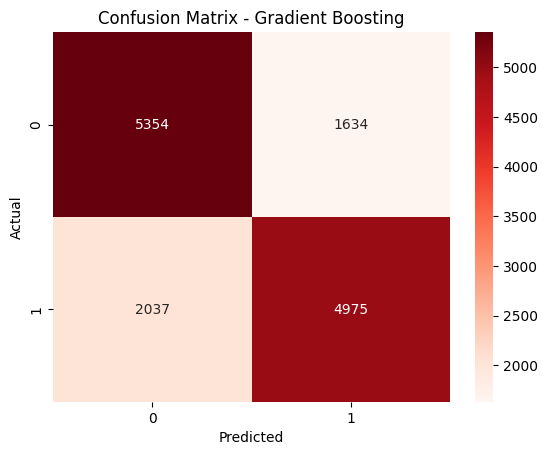

In [34]:
#confusion matrix for gradient boosting
cm_gb = confusion_matrix(y_test, y_pred_gb)

sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Reds')

plt.title("Confusion Matrix - Gradient Boosting")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [35]:
models = {
    "Random Forest": rf,
    "Gradient Boosting": gb,
    "SVM": svm,
    "KNN": knn,
    "Logistic Regression": lr
}
from sklearn.metrics import classification_report

for name, model in models.items():
    y_pred = model.predict(X_test)

    print(f"\n{name} Classification Report:\n")
    print(classification_report(y_test, y_pred))

    import pandas as pd
from sklearn.metrics import classification_report

results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    report = classification_report(y_test, y_pred, output_dict=True)

    results.append({
        "Model": name,
        "Precision": report["weighted avg"]["precision"],
        "Recall": report["weighted avg"]["recall"],
        "F1-score": report["weighted avg"]["f1-score"],
        "Accuracy": report["accuracy"]
    })

comparison_df = pd.DataFrame(results)
print(comparison_df)
comparison_df.sort_values(by="F1-score", ascending=False)


Random Forest Classification Report:

              precision    recall  f1-score   support

           0       0.71      0.73      0.72      6988
           1       0.72      0.71      0.71      7012

    accuracy                           0.72     14000
   macro avg       0.72      0.72      0.72     14000
weighted avg       0.72      0.72      0.72     14000


Gradient Boosting Classification Report:

              precision    recall  f1-score   support

           0       0.72      0.77      0.74      6988
           1       0.75      0.71      0.73      7012

    accuracy                           0.74     14000
   macro avg       0.74      0.74      0.74     14000
weighted avg       0.74      0.74      0.74     14000


SVM Classification Report:

              precision    recall  f1-score   support

           0       0.72      0.76      0.74      6988
           1       0.75      0.70      0.72      7012

    accuracy                           0.73     14000
   macro avg     

,Model,Precision,Recall,F1-score,Accuracy
1,Gradient Boosting,0.738602,0.737786,0.737581,0.737786
2,SVM,0.732806,0.731929,0.731698,0.731929
4,Logistic Regression,0.725369,0.723571,0.723053,0.723571
0,Random Forest,0.715457,0.715357,0.715332,0.715357
3,KNN,0.650064,0.649929,0.649868,0.649929


In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    roc_curve, auc,
    accuracy_score, precision_score, recall_score, f1_score
)

In [37]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_excel("Myocardial infarction dataset.xlsx")

#  Correct target column
target_col = "cardio"

#  Drop unnecessary columns
df = df.drop(["Unnamed: 0", "id"], axis=1)

# Features & target
X = df.drop(target_col, axis=1)
y = df[target_col]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

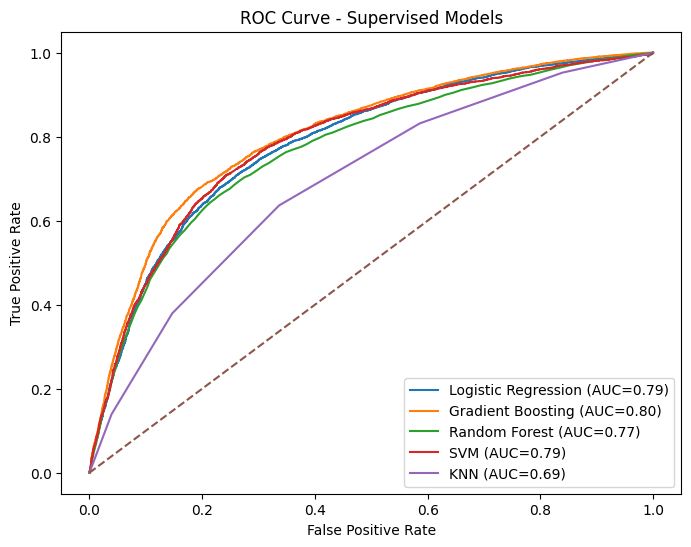

In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

models = {
    "Logistic Regression": LogisticRegression(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(probability=True),
    "KNN": KNeighborsClassifier()
}

results = []

plt.figure(figsize=(8,6))

for name, model in models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append([name, acc, prec, rec, f1])

    # ROC
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.2f})")

# Plot ROC
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Supervised Models")
plt.legend()
plt.show()

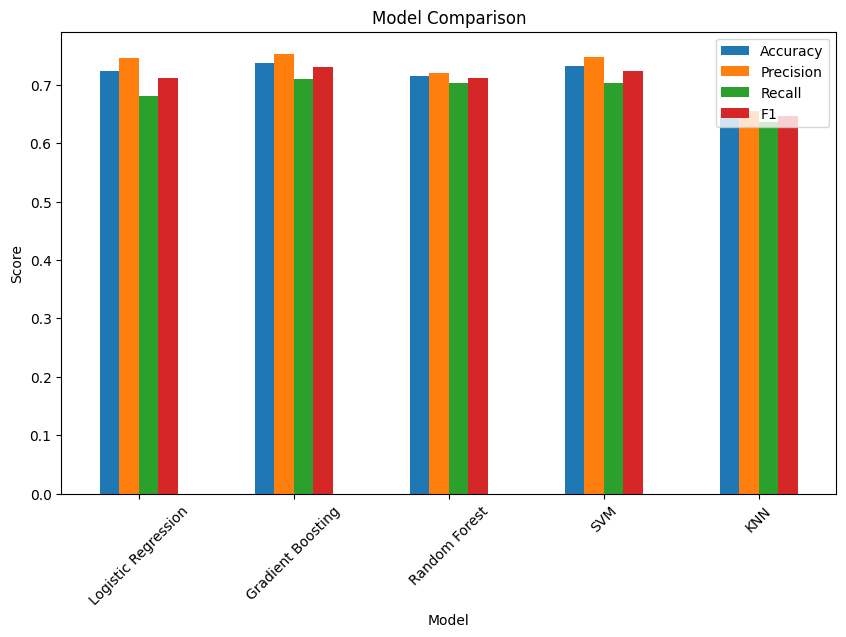

In [39]:
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1"])

results_df.set_index("Model").plot(kind="bar", figsize=(10,6))
plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.show()

In [40]:
#unsupervised ML
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.cluster import AgglomerativeClustering

from sklearn.metrics import silhouette_score

In [41]:
#loading the dataset
df = pd.read_excel("Myocardial infarction dataset.xlsx")

df.head()

,Unnamed: 0,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,0,18393,1,168,62.0,110,80,0,0,0,0,1,0
1,1,1,20228,0,156,85.0,140,90,2,0,0,0,1,1
2,2,2,18857,0,165,64.0,130,70,2,0,0,0,0,1
3,3,3,17623,1,169,82.0,150,100,0,0,0,0,1,1
4,4,4,17474,0,156,56.0,100,60,0,0,0,0,0,0


In [42]:
#checking structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   70000 non-null  int64  
 1   id           70000 non-null  int64  
 2   age          70000 non-null  int64  
 3   gender       70000 non-null  int64  
 4   height       70000 non-null  int64  
 5   weight       70000 non-null  float64
 6   ap_hi        70000 non-null  int64  
 7   ap_lo        70000 non-null  int64  
 8   cholesterol  70000 non-null  int64  
 9   gluc         70000 non-null  int64  
 10  smoke        70000 non-null  int64  
 11  alco         70000 non-null  int64  
 12  active       70000 non-null  int64  
 13  cardio       70000 non-null  int64  
dtypes: float64(1), int64(13)
memory usage: 7.5 MB


In [43]:
#data cleaning
df = df.drop(['Unnamed: 0','id'], axis=1)

In [44]:
#converting age from days to years
df['age'] = df['age'] / 365

In [45]:
#separating features and labels since it is unsupervised ML
X = df.drop('cardio', axis=1)
y = df['cardio']

In [46]:
#feature scaling
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [47]:
#PCA for visualization
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(data=X_pca, columns=['PC1','PC2'])

In [48]:
#unsupervised ML - K MEANS CLUSTERING
kmeans = KMeans(n_clusters=2, random_state=42)

kmeans_clusters = kmeans.fit_predict(X_scaled)

In [49]:
#adding cluster labels
df['kmeans_cluster'] = kmeans_clusters

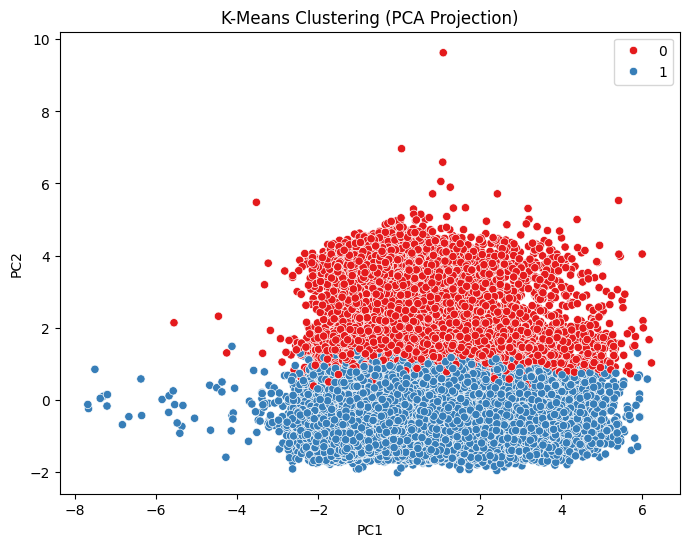

In [50]:
#k means visualization
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=pca_df['PC1'],
    y=pca_df['PC2'],
    hue=kmeans_clusters,
    palette='Set1'
)

plt.title("K-Means Clustering (PCA Projection)")
plt.show()

In [51]:
#k means evaluation
sil_kmeans = silhouette_score(X_scaled, kmeans_clusters)

print("K-Means Silhouette Score:", sil_kmeans)

K-Means Silhouette Score: 0.2670363145602759


In [52]:
#cluster comparison with disease label
pd.crosstab(df['kmeans_cluster'], df['cardio'])

cardio,0,1
kmeans_cluster,,
0,3905,8783
1,31116,26196


In [53]:
#cluster statistics
df.groupby('kmeans_cluster').mean()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
kmeans_cluster,,,,,,,,,,,,
0,55.591199,0.319830,163.809426,79.349417,142.696879,119.910151,1.506778,1.083780,0.090243,0.069515,0.811081,0.692229
1,52.840835,0.356156,164.480946,73.066948,125.744556,91.476637,0.114514,0.036659,0.087661,0.050286,0.802101,0.457077


In [54]:
#unsupervised ML - DBSCAN
dbscan = DBSCAN(eps=0.8, min_samples=20)

dbscan_clusters = dbscan.fit_predict(X_scaled)

In [55]:
#adding cluster labels
df['dbscan_cluster'] = dbscan_clusters

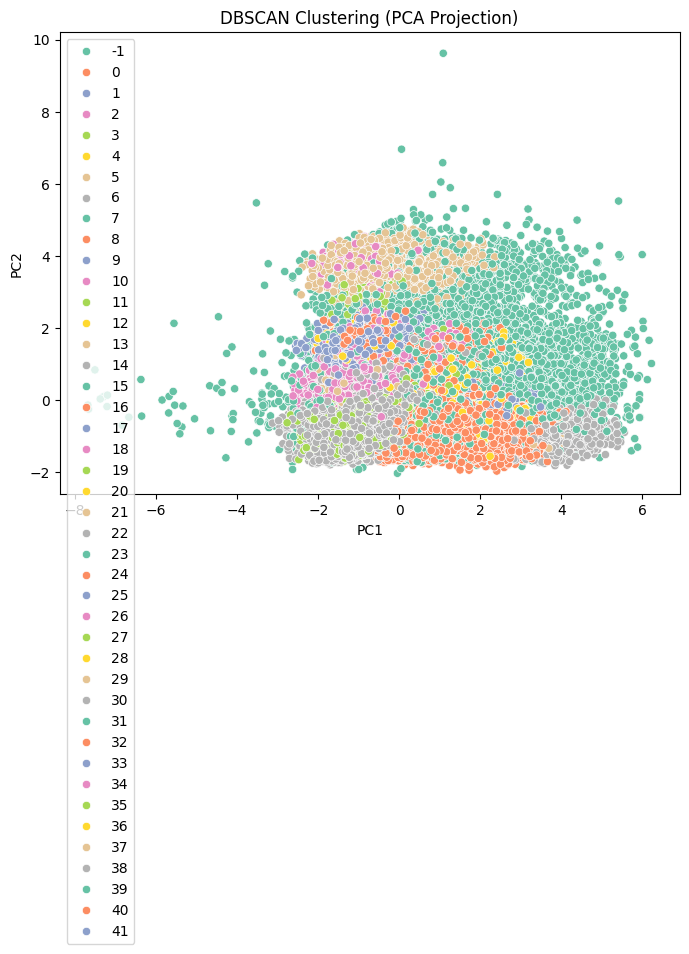

In [56]:
#dbscan visualization
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=pca_df['PC1'],
    y=pca_df['PC2'],
    hue=dbscan_clusters,
    palette='Set2'
)

plt.title("DBSCAN Clustering (PCA Projection)")
plt.show()

In [57]:
#dbscan evaluation
df['dbscan_cluster'].value_counts()

,count
dbscan_cluster,
6,23864
0,10282
-1,6432
3,5871
10,3261
7,2704
1,2079
8,2025
13,1737


In [58]:
#comparing with disease label
pd.crosstab(df['dbscan_cluster'], df['cardio'])

cardio,0,1
dbscan_cluster,,
-1,2361,4071
0,5783,4499
1,351,1728
2,54,291
3,3154,2717
4,100,158
5,177,392
6,13921,9943
7,1311,1393


In [59]:
#removing noise points before sihouette score
mask = dbscan_clusters != -1

sil_dbscan = silhouette_score(X_scaled[mask], dbscan_clusters[mask])

print("DBSCAN Silhouette Score:", sil_dbscan)

DBSCAN Silhouette Score: 0.21533822613446943


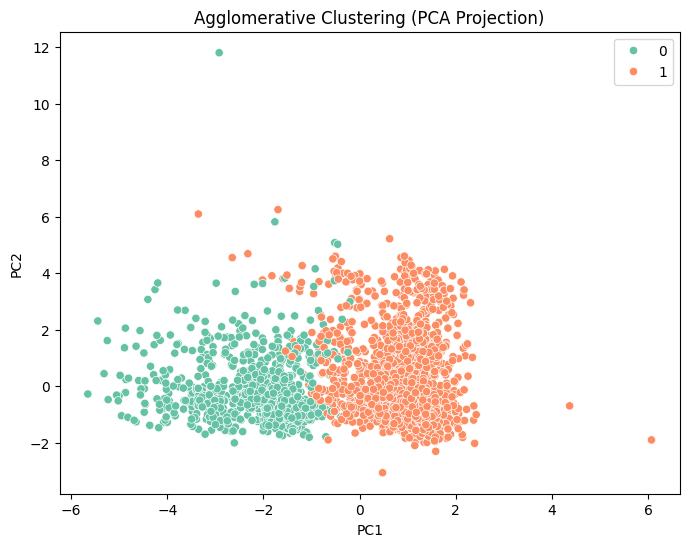

Agglomerative Silhouette Score: 0.27810294912008626

Cluster vs Disease Label:
cardio            0     1
agglo_cluster            
0               460   441
1              1033  1066

Cluster Mean Values:
                        age    gender      height     weight       ap_hi  \
agglo_cluster                                                              
0              19276.809101  0.872364  169.179800  76.758380  129.390677   
1              19575.676989  0.125298  162.414007  72.789138  125.690329   

                    ap_lo  cholesterol      gluc     smoke      alco  \
agglo_cluster                                                          
0              120.948946     0.299667  0.063263  0.287458  0.174251   
1               80.910434     0.378752  0.270605  0.006193  0.001429   

                 active    cardio  
agglo_cluster                      
0              0.940067  0.489456  
1              0.734159  0.507861  


In [4]:
# Importing required libraries
import pandas as pd

# Loading dataset
df = df.sample(n=3000, random_state=42)
from sklearn.preprocessing import StandardScaler

# Features (dropping target)
X = df.drop("cardio", axis=1)

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Agglomerative Clustering Model

agglo = AgglomerativeClustering(n_clusters=2)

# Fitting and predicting clusters
agglo_clusters = agglo.fit_predict(X_scaled)

# Adding cluster labels to dataframe
df['agglo_cluster'] = agglo_clusters
from sklearn.decomposition import PCA

# Reducing to 2D for visualization
pca = PCA(n_components=2)
pca_components = pca.fit_transform(X_scaled)

# Creating dataframe for plotting
pca_df = pd.DataFrame(pca_components, columns=["PC1", "PC2"])

# Visualization (PCA Projection)

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=pca_df['PC1'],
    y=pca_df['PC2'],
    hue=agglo_clusters,
    palette='Set2'
)

plt.title("Agglomerative Clustering (PCA Projection)")
plt.show()

# Evaluation (Silhouette Score)

sil_agglo = silhouette_score(X_scaled, agglo_clusters)
print("Agglomerative Silhouette Score:", sil_agglo)


# Cluster vs Target Comparison

print("\nCluster vs Disease Label:")
print(pd.crosstab(df['agglo_cluster'], df['cardio']))


# Cluster Statistics

print("\nCluster Mean Values:")
print(df.groupby('agglo_cluster').mean())

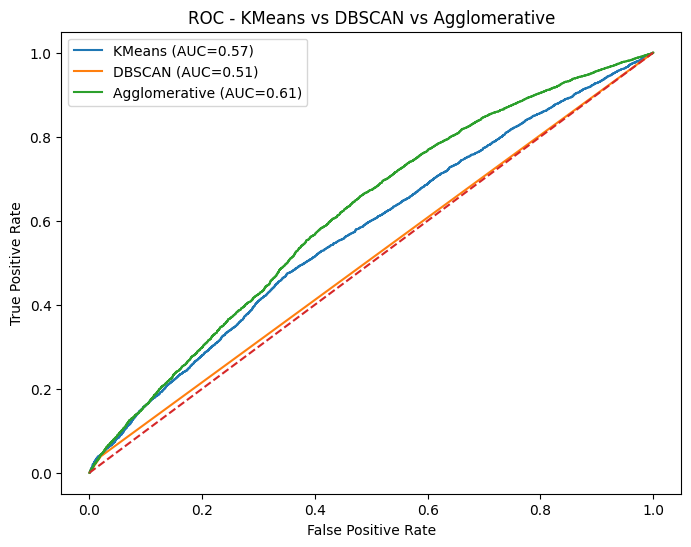

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc

from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.neighbors import NearestNeighbors
import numpy as np

# Loading dataset
df = pd.read_excel("Myocardial infarction dataset.xlsx")

# Target
target_col = "cardio"

# Dropping unwanted columns
df = df.drop(["Unnamed: 0", "id"], axis=1)

# Features & target
X = df.drop(target_col, axis=1)
y = df[target_col]

# Splitting
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

plt.figure(figsize=(8,6))

# KMEANS
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X_train)

distances = kmeans.transform(X_test)
scores_kmeans = np.min(distances, axis=1)

scores_kmeans = (scores_kmeans - scores_kmeans.min()) / (scores_kmeans.max() - scores_kmeans.min())

fpr, tpr, _ = roc_curve(y_test, scores_kmeans)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"KMeans (AUC={roc_auc:.2f})")


# DBSCAN
dbscan = DBSCAN(eps=1.5, min_samples=5)
labels = dbscan.fit_predict(X_test)

scores_dbscan = np.where(labels == -1, 1, 0)

fpr, tpr, _ = roc_curve(y_test, scores_dbscan)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"DBSCAN (AUC={roc_auc:.2f})")


# AGGLOMERATIVE
agglo = AgglomerativeClustering(n_clusters=2)
agglo_labels = agglo.fit_predict(X_test)

# Converting clustering output to anomaly score
# Using distance to nearest neighbors (since Agglo has no predict/transform)
nn = NearestNeighbors(n_neighbors=5)
nn.fit(X_test)

distances, _ = nn.kneighbors(X_test)
scores_agglo = np.mean(distances, axis=1)

# Normalizing
scores_agglo = (scores_agglo - scores_agglo.min()) / (scores_agglo.max() - scores_agglo.min())

# ROC CURVE
fpr, tpr, _ = roc_curve(y_test, scores_agglo)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"Agglomerative (AUC={roc_auc:.2f})")


# FINAL PLOT
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC - KMeans vs DBSCAN vs Agglomerative")
plt.legend()
plt.show()

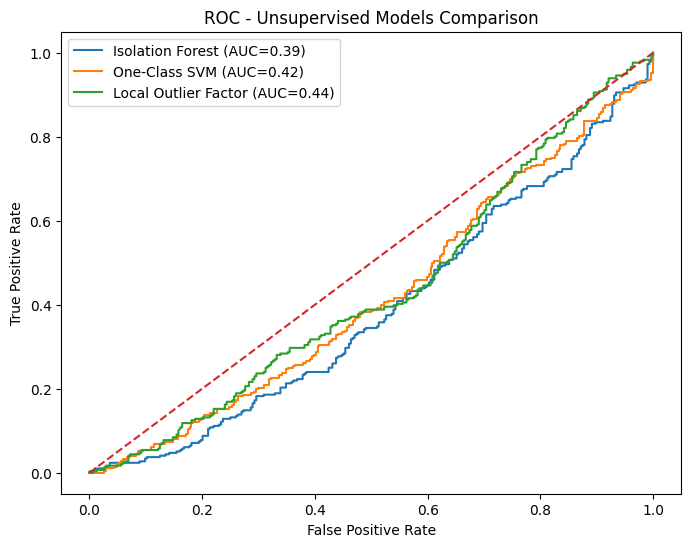

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc

from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor

# Loading dataset
df = df.sample(n=3000, random_state=42)

# Correcting target
target_col = "cardio"
df = df.drop(["Unnamed: 0", "id"], axis=1, errors='ignore')


# Features & target
X = df.drop(target_col, axis=1)
y = df[target_col]

# Splitting
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Unsupervised models
models = {
    "Isolation Forest": IsolationForest(contamination=0.1, random_state=42),
    "One-Class SVM": OneClassSVM(),
    "Local Outlier Factor": LocalOutlierFactor(novelty=True)
}

plt.figure(figsize=(8,6))

for name, model in models.items():

    model.fit(X_train)

    # Getting anomaly scores
    scores = model.decision_function(X_test)

    # Normalizing scores (important for ROC)
    scores = (scores - scores.min()) / (scores.max() - scores.min())

    # ROC
    fpr, tpr, _ = roc_curve(y_test, scores)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.2f})")

# Plot
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC - Unsupervised Models Comparison")
plt.legend()
plt.show()